# Notebook 03

In [ ]:
# ============================================
# 1. SETUP
# ============================================

!pip install tensorflow pandas numpy matplotlib seaborn scikit-learn scipy plotly -q

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
import os
import shutil
from datetime import datetime
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_recall_curve, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')
import glob
import zipfile
import time
from pathlib import Path

from google.colab import drive
drive.mount('/content/drive')

print(f"✅ TensorFlow version: {tf.__version__}")
print(f"✅ GPU available: {tf.config.list_physical_devices('GPU')}")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ TensorFlow version: 2.19.0
✅ GPU available: []


In [ ]:
# ============================================
# 2. CONFIGURATION
# ============================================

class Config:
    # Paths
    DATA_PATH = "/content/drive/MyDrive/Research/SLSL_Model_Data/"
    OUTPUT_DIR = "/content/drive/MyDrive/Research/SLSL_Model_Results/"

    # Multi-modal dimensions
    LEFT_HAND_DIM = 84
    RIGHT_HAND_DIM = 84
    POSE_DIM = 100
    LIP_DIM = 200

    # Data processing
    SEQUENCE_SLICE_RATIO = 2  # 560 -> 280 frames
    BATCH_SIZE = 10

    # Enhanced Architecture - Your requested specs
    HAND_CONV1 = 64
    HAND_CONV2 = 128
    HAND_DENSE = 64

    POSE_CONV = 32
    POSE_DENSE = 32

    LIP_CONV = 64
    LIP_LSTM1 = 64
    LIP_LSTM2 = 32

    FUSION_UNITS = 128

    # Regularization
    DROPOUT_RATE = 0.5
    L2_REG = 0.01

    # Training
    LEARNING_RATE = 0.0005
    EPOCHS = 100
    PATIENCE = 15
    REDUCE_LR_PATIENCE = 5

    # Data augmentation
    USE_AUGMENTATION = False
    NOISE_STD = 0.05
    DROPOUT_FRAMES = 0.1

    # Random seed
    RANDOM_SEED = 42

cfg = Config()

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

print("="*60)
print("ENHANCED MULTI-MODAL CONFIGURATION")
print("="*60)
print(f"Hand Stream: Conv1D({cfg.HAND_CONV1})→Conv1D({cfg.HAND_CONV2})→Dense({cfg.HAND_DENSE})")
print(f"Pose Stream: Conv1D({cfg.POSE_CONV})→Dense({cfg.POSE_DENSE})")
print(f"Lip Stream: Conv1D({cfg.LIP_CONV})→LSTM({cfg.LIP_LSTM1})→LSTM({cfg.LIP_LSTM2})")
print(f"Dropout: {cfg.DROPOUT_RATE}, L2: {cfg.L2_REG}")
print("="*60)

# Set seeds
tf.random.set_seed(cfg.RANDOM_SEED)
np.random.seed(cfg.RANDOM_SEED)



ENHANCED MULTI-MODAL CONFIGURATION
Hand Stream: Conv1D(64)→Conv1D(128)→Dense(64)
Pose Stream: Conv1D(32)→Dense(32)
Lip Stream: Conv1D(64)→LSTM(64)→LSTM(32)
Dropout: 0.5, L2: 0.01


In [ ]:
# ============================================
# 3. LOAD DATA
# ============================================

def load_multi_modal_data(data_path, slice_ratio=4):
    """Load data and split into modalities"""

    print("\n📂 LOADING MULTI-MODAL DATA")
    print("="*60)

    X_train = np.load(os.path.join(data_path, 'X_train.npy'))
    X_val = np.load(os.path.join(data_path, 'X_val.npy'))
    X_test = np.load(os.path.join(data_path, 'X_test.npy'))

    y_train = np.load(os.path.join(data_path, 'y_train.npy'))
    y_val = np.load(os.path.join(data_path, 'y_val.npy'))
    y_test = np.load(os.path.join(data_path, 'y_test.npy'))

    classes = np.load(os.path.join(data_path, 'classes.npy'), allow_pickle=True)

    # Reduce sequence length
    X_train = X_train[:, ::slice_ratio, :]
    X_val = X_val[:, ::slice_ratio, :]
    X_test = X_test[:, ::slice_ratio, :]

    cfg.SEQUENCE_LENGTH = X_train.shape[1]

    # Split into modalities
    def split_modalities(X):
        left = X[:, :, :cfg.LEFT_HAND_DIM]
        right = X[:, :, cfg.LEFT_HAND_DIM:cfg.LEFT_HAND_DIM+cfg.RIGHT_HAND_DIM]
        pose = X[:, :, cfg.LEFT_HAND_DIM+cfg.RIGHT_HAND_DIM:cfg.LEFT_HAND_DIM+cfg.RIGHT_HAND_DIM+cfg.POSE_DIM]
        lip = X[:, :, cfg.LEFT_HAND_DIM+cfg.RIGHT_HAND_DIM+cfg.POSE_DIM:]
        return left, right, pose, lip

    left_train, right_train, pose_train, lip_train = split_modalities(X_train)
    left_val, right_val, pose_val, lip_val = split_modalities(X_val)
    left_test, right_test, pose_test, lip_test = split_modalities(X_test)

    print(f"\n📊 DATA SHAPES:")
    print(f"   Training: {len(y_train)} samples, {cfg.SEQUENCE_LENGTH} frames")
    print(f"   Validation: {len(y_val)} samples")
    print(f"   Test: {len(y_test)} samples")
    print(f"   Classes: {len(classes)}")

    return {
        'left_train': left_train.astype(np.float32),
        'right_train': right_train.astype(np.float32),
        'pose_train': pose_train.astype(np.float32),
        'lip_train': lip_train.astype(np.float32),
        'left_val': left_val.astype(np.float32),
        'right_val': right_val.astype(np.float32),
        'pose_val': pose_val.astype(np.float32),
        'lip_val': lip_val.astype(np.float32),
        'left_test': left_test.astype(np.float32),
        'right_test': right_test.astype(np.float32),
        'pose_test': pose_test.astype(np.float32),
        'lip_test': lip_test.astype(np.float32),
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
        'classes': classes,
        'num_classes': len(classes)
    }

data = load_multi_modal_data(cfg.DATA_PATH, cfg.SEQUENCE_SLICE_RATIO)

# One-hot encode labels
y_train_cat = tf.keras.utils.to_categorical(data['y_train'], data['num_classes'])
y_val_cat = tf.keras.utils.to_categorical(data['y_val'], data['num_classes'])
y_test_cat = tf.keras.utils.to_categorical(data['y_test'], data['num_classes'])




📂 LOADING MULTI-MODAL DATA

📊 DATA SHAPES:
   Training: 165 samples, 280 frames
   Validation: 39 samples
   Test: 51 samples
   Classes: 10


In [ ]:
# ============================================
# 4. DATA AUGMENTATION
# ============================================

def augment_multi_modal_data(left, right, pose, lip, y):
    """Apply data augmentation"""

    # Add Gaussian noise
    left_noise = left + np.random.normal(0, cfg.NOISE_STD, left.shape)
    right_noise = right + np.random.normal(0, cfg.NOISE_STD, right.shape)
    pose_noise = pose + np.random.normal(0, cfg.NOISE_STD, pose.shape)
    lip_noise = lip + np.random.normal(0, cfg.NOISE_STD, lip.shape)

    # Time masking
    mask = np.random.random(left.shape[:2]) > cfg.DROPOUT_FRAMES
    left_masked = left * mask[:, :, np.newaxis]
    right_masked = right * mask[:, :, np.newaxis]
    pose_masked = pose * mask[:, :, np.newaxis]
    lip_masked = lip * mask[:, :, np.newaxis]

    # Concatenate
    left_aug = np.concatenate([left, left_noise, left_masked], axis=0)
    right_aug = np.concatenate([right, right_noise, right_masked], axis=0)
    pose_aug = np.concatenate([pose, pose_noise, pose_masked], axis=0)
    lip_aug = np.concatenate([lip, lip_noise, lip_masked], axis=0)
    y_aug = np.concatenate([y, y, y], axis=0)

    print(f"   Augmented: {len(y)} → {len(y_aug)} samples")

    return left_aug, right_aug, pose_aug, lip_aug, y_aug

if cfg.USE_AUGMENTATION:
    print("\n🔄 APPLYING DATA AUGMENTATION")
    print("="*60)
    data['left_train'], data['right_train'], data['pose_train'], data['lip_train'], data['y_train'] = augment_multi_modal_data(
        data['left_train'], data['right_train'], data['pose_train'], data['lip_train'], data['y_train']
    )
    y_train_cat = tf.keras.utils.to_categorical(data['y_train'], data['num_classes'])



In [ ]:
# ============================================
# 5. ENHANCED MULTI-MODAL MODEL (Your Architecture)
# ============================================

def create_enhanced_multi_modal_model(cfg, num_classes):
    """
    Enhanced Multi-modal Model with your specified architecture:
    - Hand: Conv1D(64) → Conv1D(128) → Dense(64)
    - Pose: Conv1D(32) → Dense(32)
    - Lip: Conv1D(64) → LSTM(64) → LSTM(32)
    """

    # Input layers
    left_input = layers.Input(shape=(cfg.SEQUENCE_LENGTH, cfg.LEFT_HAND_DIM), name='left_hand')
    right_input = layers.Input(shape=(cfg.SEQUENCE_LENGTH, cfg.RIGHT_HAND_DIM), name='right_hand')
    pose_input = layers.Input(shape=(cfg.SEQUENCE_LENGTH, cfg.POSE_DIM), name='pose')
    lip_input = layers.Input(shape=(cfg.SEQUENCE_LENGTH, cfg.LIP_DIM), name='lip')

    # ============================================
    # LEFT HAND STREAM (Conv1D64 → Conv1D128 → Dense64)
    # ============================================
    left = layers.Conv1D(cfg.HAND_CONV1, 3, padding='same', activation='relu',
                         kernel_regularizer=regularizers.l2(cfg.L2_REG))(left_input)
    left = layers.BatchNormalization()(left)
    left = layers.Dropout(cfg.DROPOUT_RATE)(left)

    left = layers.Conv1D(cfg.HAND_CONV2, 3, padding='same', activation='relu',
                         kernel_regularizer=regularizers.l2(cfg.L2_REG))(left)
    left = layers.BatchNormalization()(left)
    left = layers.GlobalAveragePooling1D()(left)

    left = layers.Dense(cfg.HAND_DENSE, activation='relu',
                        kernel_regularizer=regularizers.l2(cfg.L2_REG))(left)
    left = layers.Dropout(cfg.DROPOUT_RATE)(left)

    # ============================================
    # RIGHT HAND STREAM (Conv1D64 → Conv1D128 → Dense64)
    # ============================================
    right = layers.Conv1D(cfg.HAND_CONV1, 3, padding='same', activation='relu',
                          kernel_regularizer=regularizers.l2(cfg.L2_REG))(right_input)
    right = layers.BatchNormalization()(right)
    right = layers.Dropout(cfg.DROPOUT_RATE)(right)

    right = layers.Conv1D(cfg.HAND_CONV2, 3, padding='same', activation='relu',
                          kernel_regularizer=regularizers.l2(cfg.L2_REG))(right)
    right = layers.BatchNormalization()(right)
    right = layers.GlobalAveragePooling1D()(right)

    right = layers.Dense(cfg.HAND_DENSE, activation='relu',
                         kernel_regularizer=regularizers.l2(cfg.L2_REG))(right)
    right = layers.Dropout(cfg.DROPOUT_RATE)(right)

    # ============================================
    # POSE STREAM (Conv1D32 → Dense32)
    # ============================================
    pose = layers.Conv1D(cfg.POSE_CONV, 3, padding='same', activation='relu',
                         kernel_regularizer=regularizers.l2(cfg.L2_REG))(pose_input)
    pose = layers.BatchNormalization()(pose)
    pose = layers.GlobalAveragePooling1D()(pose)

    pose = layers.Dense(cfg.POSE_DENSE, activation='relu',
                        kernel_regularizer=regularizers.l2(cfg.L2_REG))(pose)
    pose = layers.Dropout(cfg.DROPOUT_RATE)(pose)

    # ============================================
    # LIP STREAM (Conv1D64 → LSTM64 → LSTM32)
    # ============================================
    lip = layers.Conv1D(cfg.LIP_CONV, 3, padding='same', activation='relu',
                        kernel_regularizer=regularizers.l2(cfg.L2_REG))(lip_input)
    lip = layers.BatchNormalization()(lip)
    lip = layers.Dropout(cfg.DROPOUT_RATE)(lip)

    lip = layers.LSTM(cfg.LIP_LSTM1, return_sequences=True,
                      dropout=cfg.DROPOUT_RATE, recurrent_dropout=cfg.DROPOUT_RATE)(lip)
    lip = layers.LSTM(cfg.LIP_LSTM2, dropout=cfg.DROPOUT_RATE,
                      recurrent_dropout=cfg.DROPOUT_RATE)(lip)
    lip = layers.Dropout(cfg.DROPOUT_RATE)(lip)

    # ============================================
    # MULTI-MODAL FUSION
    # ============================================
    fused = layers.Concatenate(name='fusion')([left, right, pose, lip])

    fused = layers.Dense(cfg.FUSION_UNITS, activation='relu',
                         kernel_regularizer=regularizers.l2(cfg.L2_REG))(fused)
    fused = layers.BatchNormalization()(fused)
    fused = layers.Dropout(cfg.DROPOUT_RATE)(fused)

    fused = layers.Dense(cfg.FUSION_UNITS // 2, activation='relu',
                         kernel_regularizer=regularizers.l2(cfg.L2_REG))(fused)
    fused = layers.Dropout(cfg.DROPOUT_RATE/2)(fused)

    # Output
    output = layers.Dense(num_classes, activation='softmax', name='output')(fused)

    model = Model(
        inputs=[left_input, right_input, pose_input, lip_input],
        outputs=output,
        name='Enhanced_MultiModal_SLSL'
    )

    return model

print("\n" + "="*60)
print("🏗️ BUILDING ENHANCED MULTI-MODAL MODEL")
print("="*60)

model = create_enhanced_multi_modal_model(cfg, data['num_classes'])
model.summary()

total_params = model.count_params()
print(f"\n📊 MODEL COMPLEXITY:")
print(f"   Total parameters: {total_params:,}")
print(f"   Parameters per sample: {total_params / len(data['y_train']):.0f}")




🏗️ BUILDING ENHANCED MULTI-MODAL MODEL


Model: "Enhanced_MultiModal_SLSL"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ left_hand           │ (None, 280, 84)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ right_hand          │ (None, 280, 84)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_38 (Conv1D)  │ (None, 280, 64)   │     16,192 │ left_hand[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_40 (Conv1D)  │ (None, 280, 64)   │     16,192 │ right_hand[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 280, 64)   │        256 │ conv1d_38[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 280, 64)   │        256 │ conv1d_40[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lip (InputLayer)    │ (None, 280, 200)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_60          │ (None, 280, 64)   │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_62          │ (None, 280, 64)   │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pose (InputLayer)   │ (None, 280, 100)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_43 (Conv1D)  │ (None, 280, 64)   │     38,464 │ lip[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_39 (Conv1D)  │ (None, 280, 128)  │     24,704 │ dropout_60[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_41 (Conv1D)  │ (None, 280, 128)  │     24,704 │ dropout_62[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_42 (Conv1D)  │ (None, 280, 32)   │      9,632 │ pose[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 280, 64)   │        256 │ conv1d_43[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 280, 128)  │        512 │ conv1d_39[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 280, 128)  │        512 │ conv1d_41[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 280, 32)   │        128 │ conv1d_42[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_65          │ (None, 280, 64)   │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 228,938 (894.29 KB)

 Trainable params: 227,722 (889.54 KB)

 Non-trainable params: 1,216 (4.75 KB)


📊 MODEL COMPLEXITY:
   Total parameters: 228,938
   Parameters per sample: 1388


In [ ]:
# ============================================
# 6. COMPILE MODEL
# ============================================

optimizer = keras.optimizers.AdamW(
    learning_rate=cfg.LEARNING_RATE,
    weight_decay=0.001
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc'),
        keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

print("\n✅ Model compiled with AdamW optimizer")




✅ Model compiled with AdamW optimizer


In [ ]:
# ============================================
# 7. CLASS WEIGHTS
# ============================================

classes = np.unique(data['y_train'])
weights = compute_class_weight('balanced', classes=classes, y=data['y_train'])
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}

print("\n⚖️ CLASS WEIGHTS:")
for class_id, weight in list(class_weight.items())[:5]:
    print(f"   Class {class_id}: {weight:.3f}")




⚖️ CLASS WEIGHTS:
   Class 0: 1.269
   Class 1: 1.269
   Class 2: 1.269
   Class 3: 0.868
   Class 4: 1.031



📊 CREATING COMPREHENSIVE VISUALIZATIONS


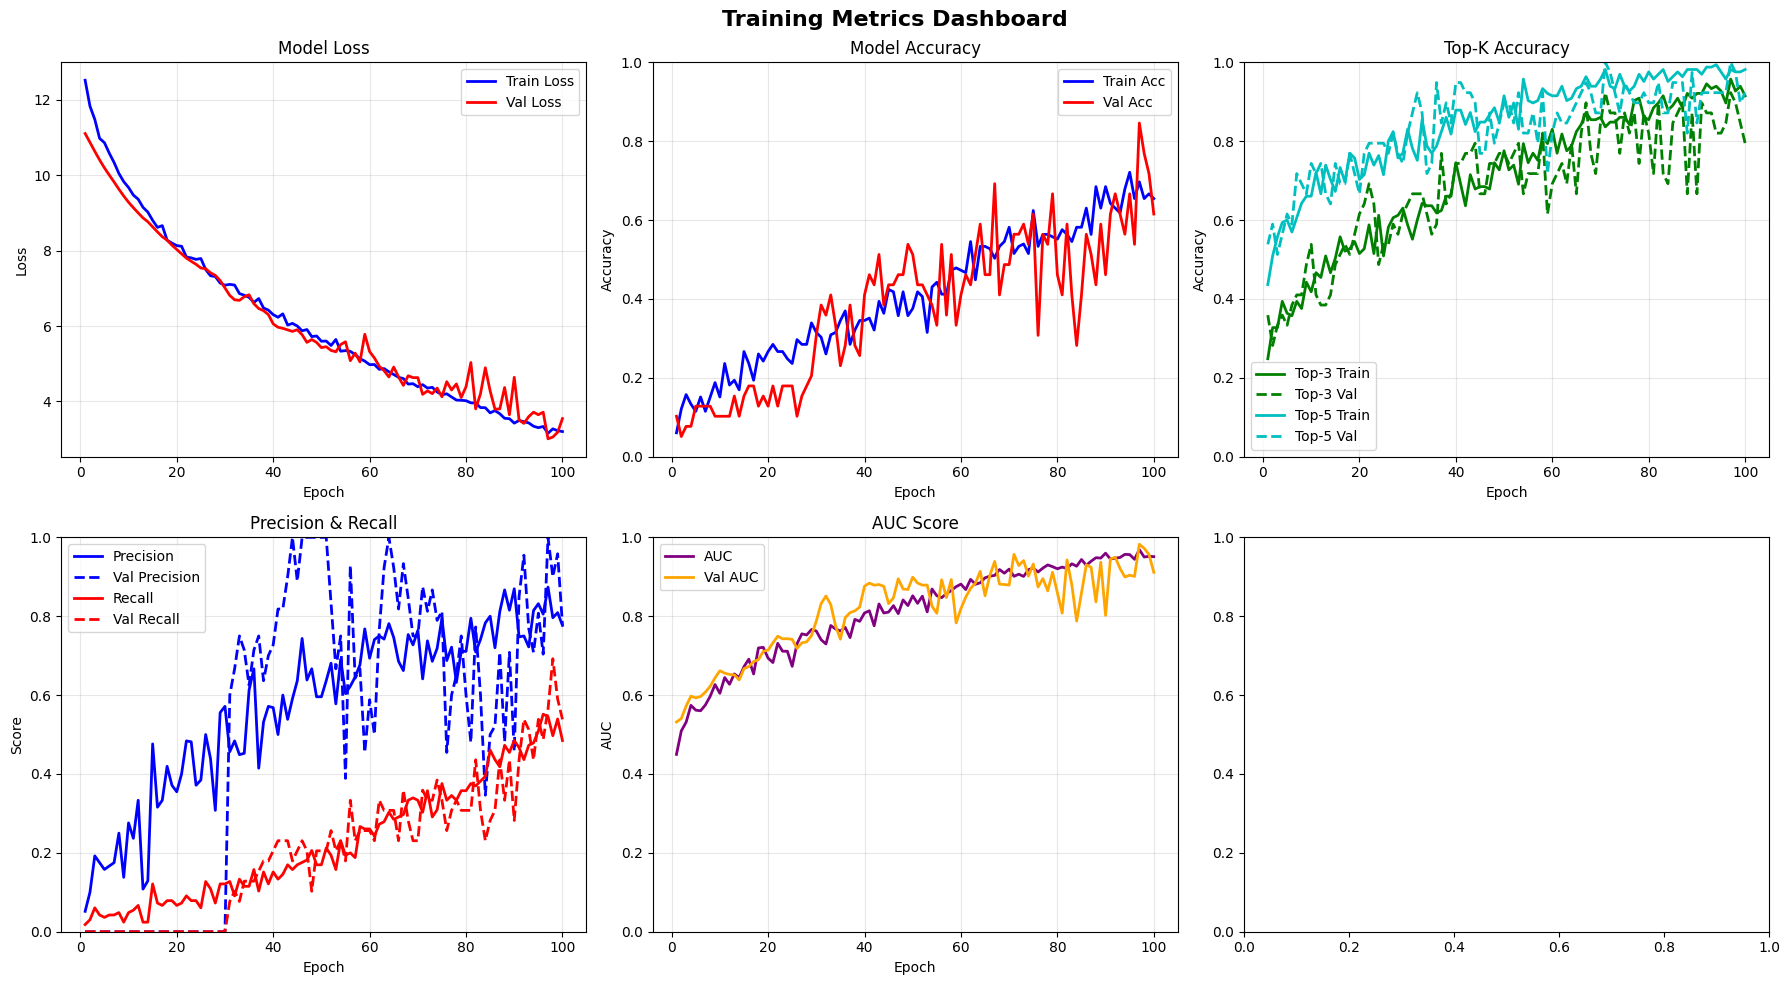

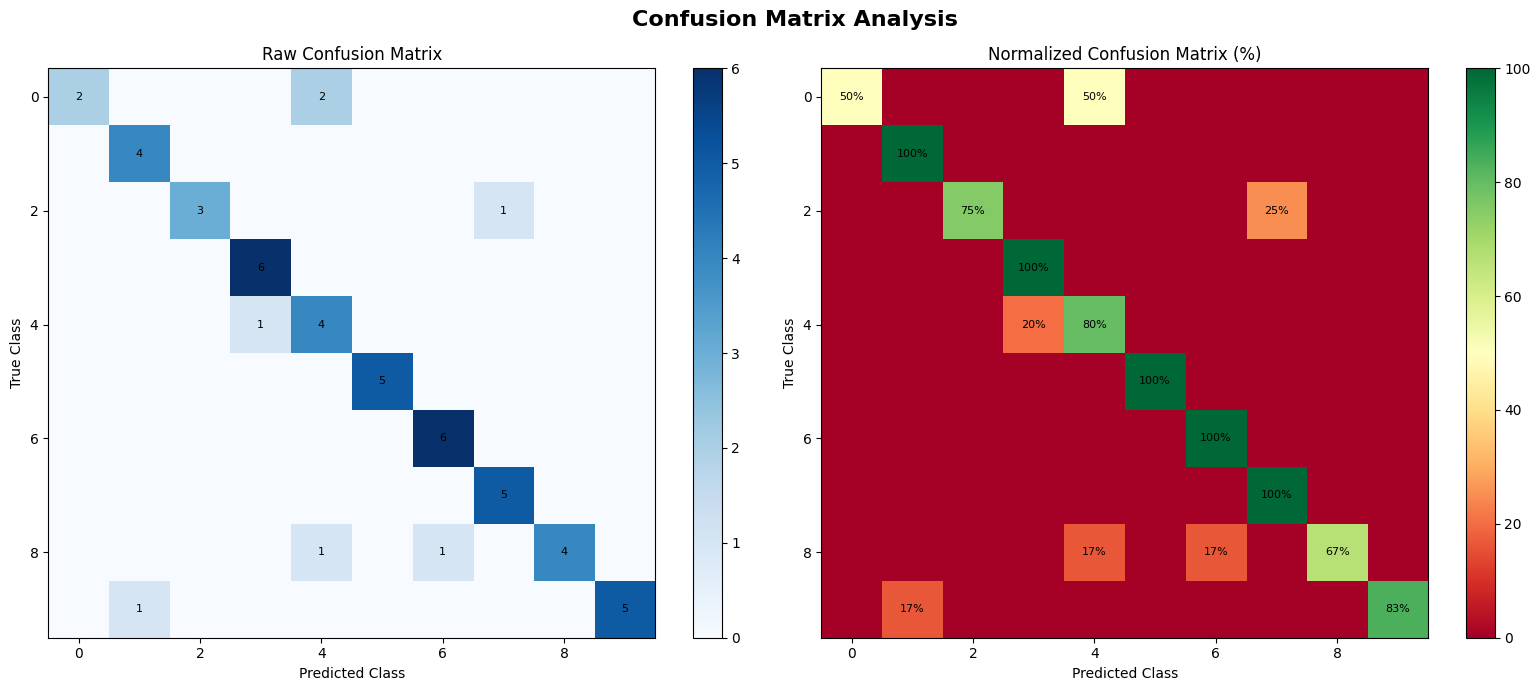

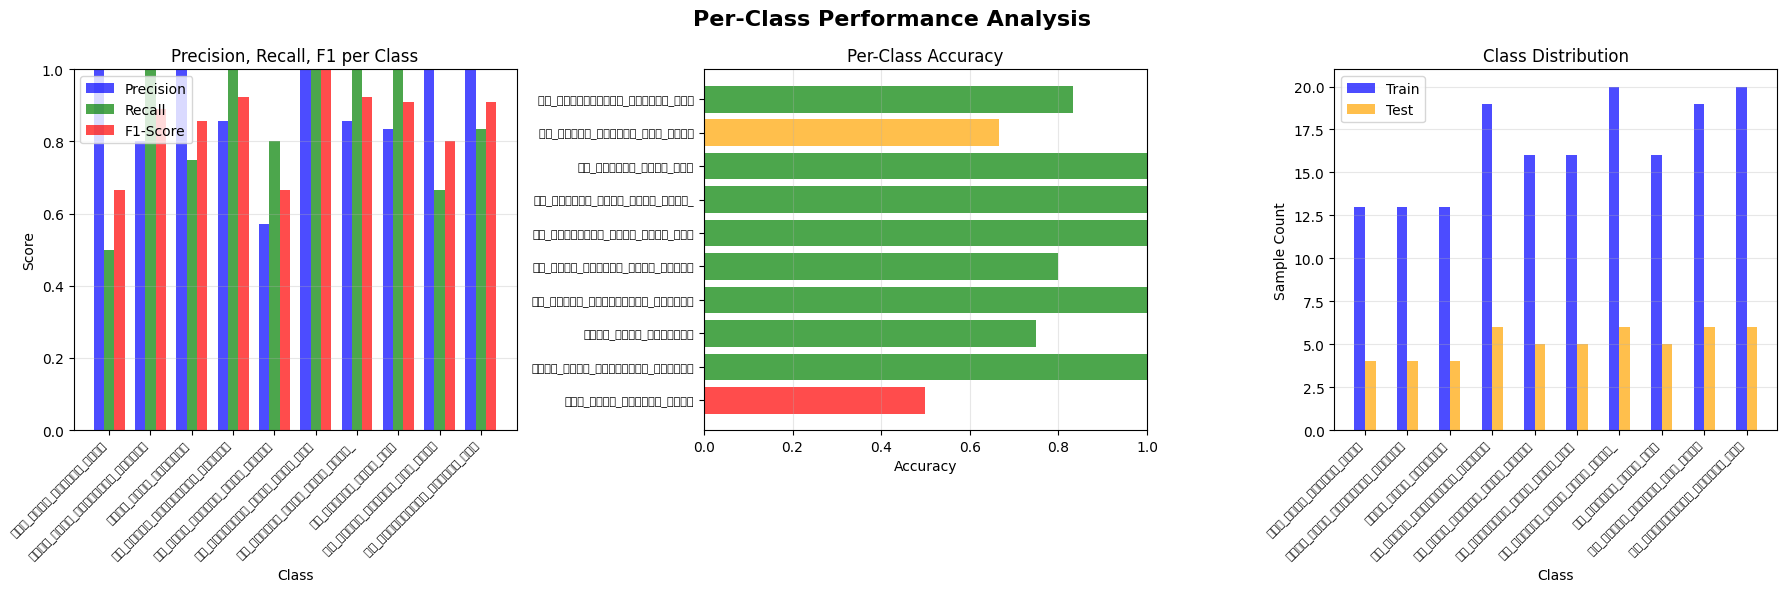

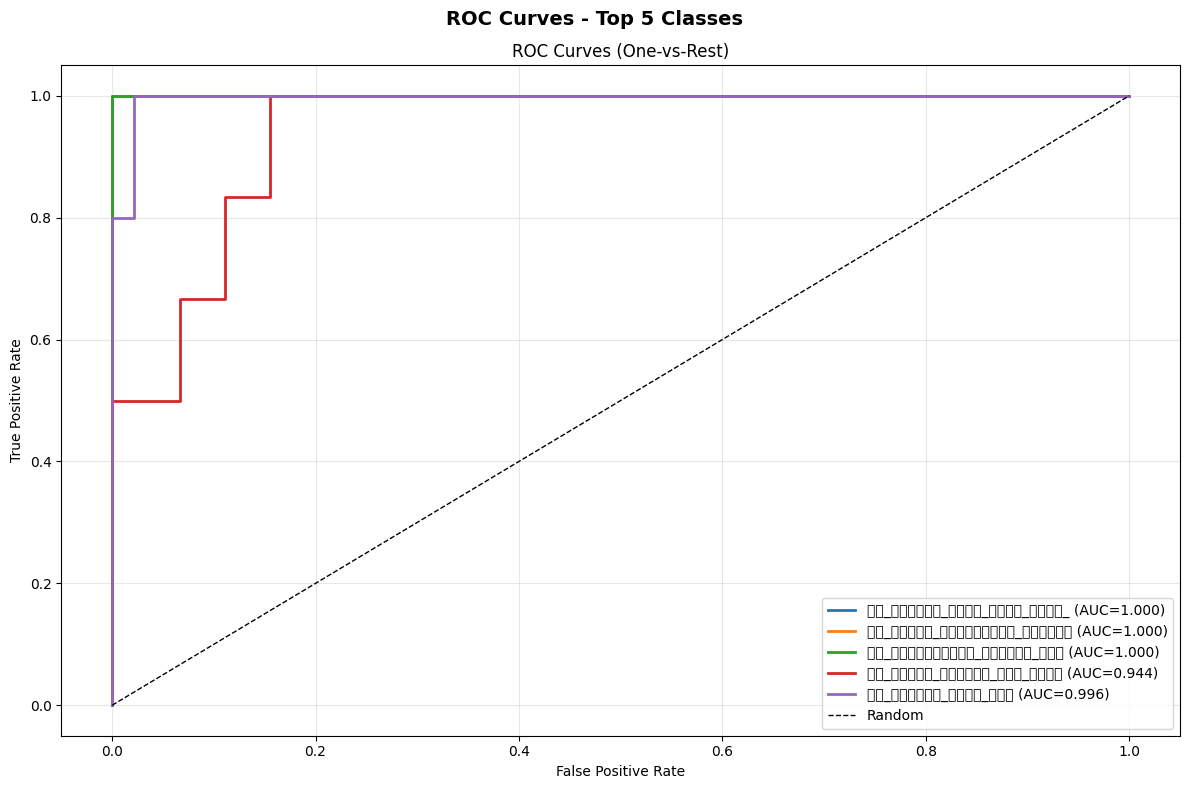

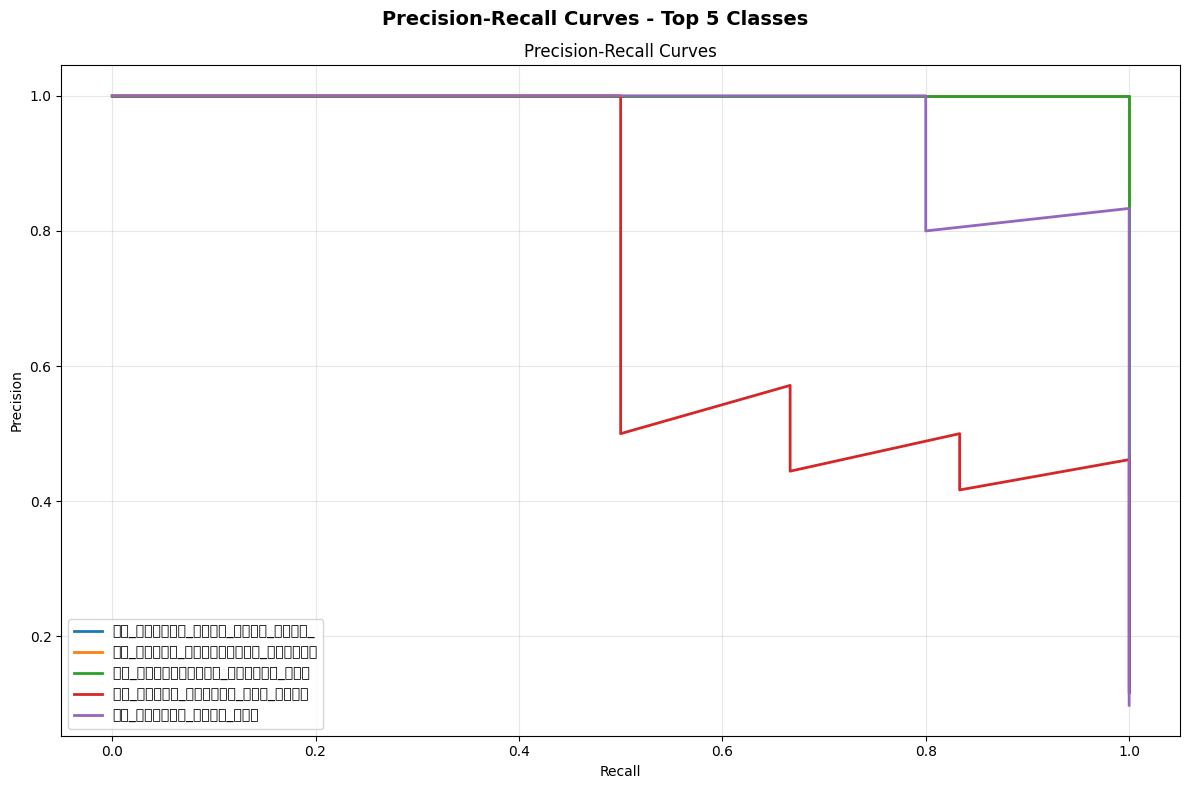

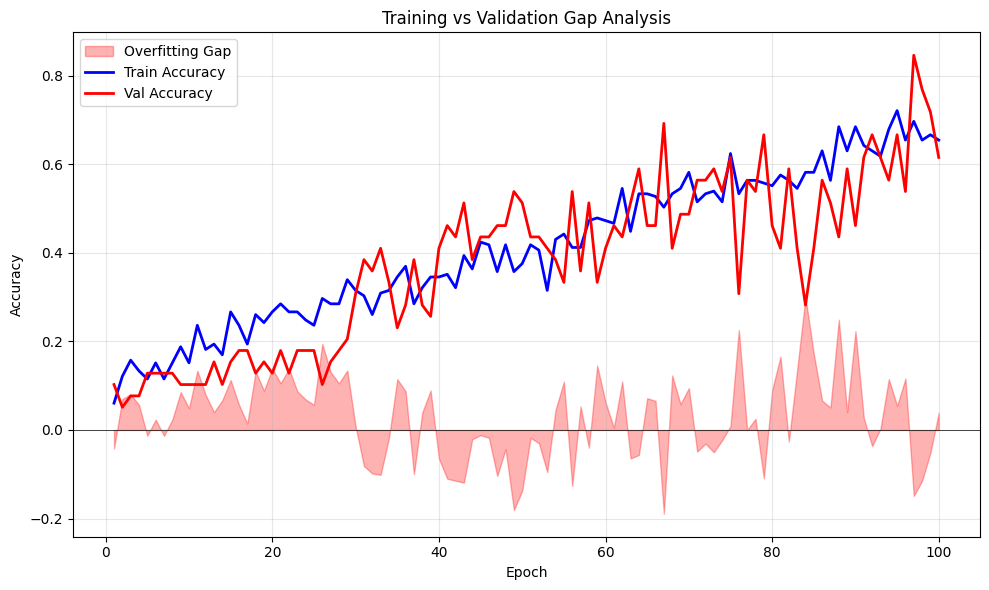

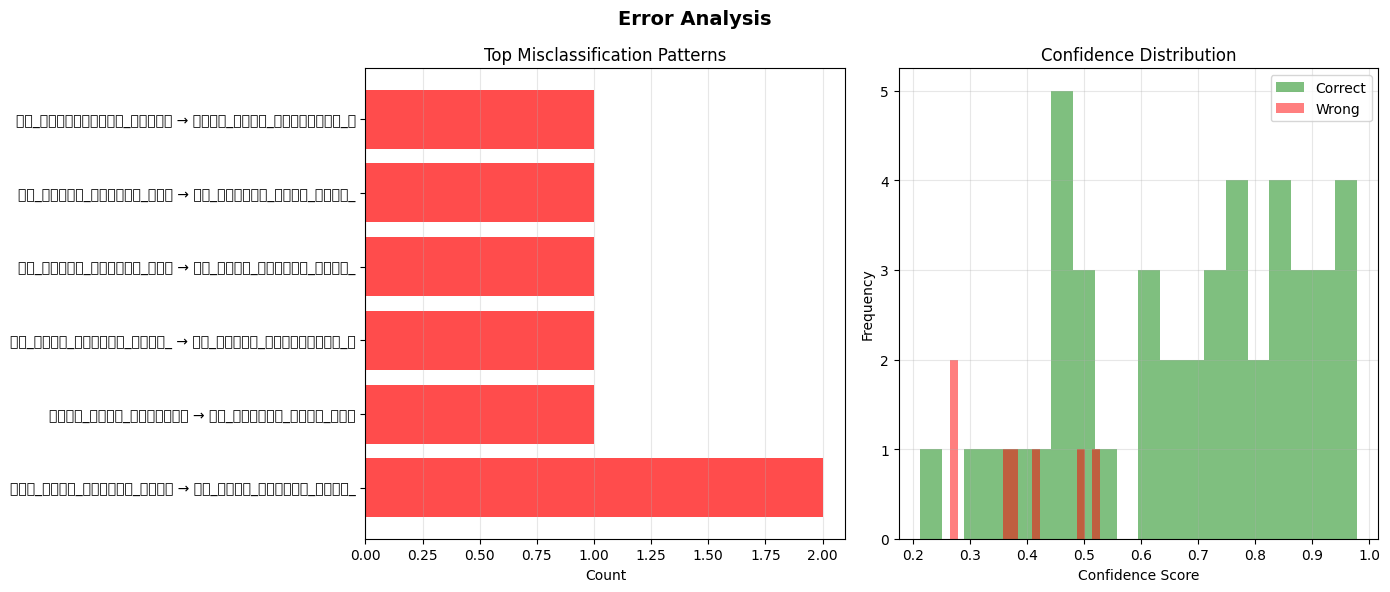

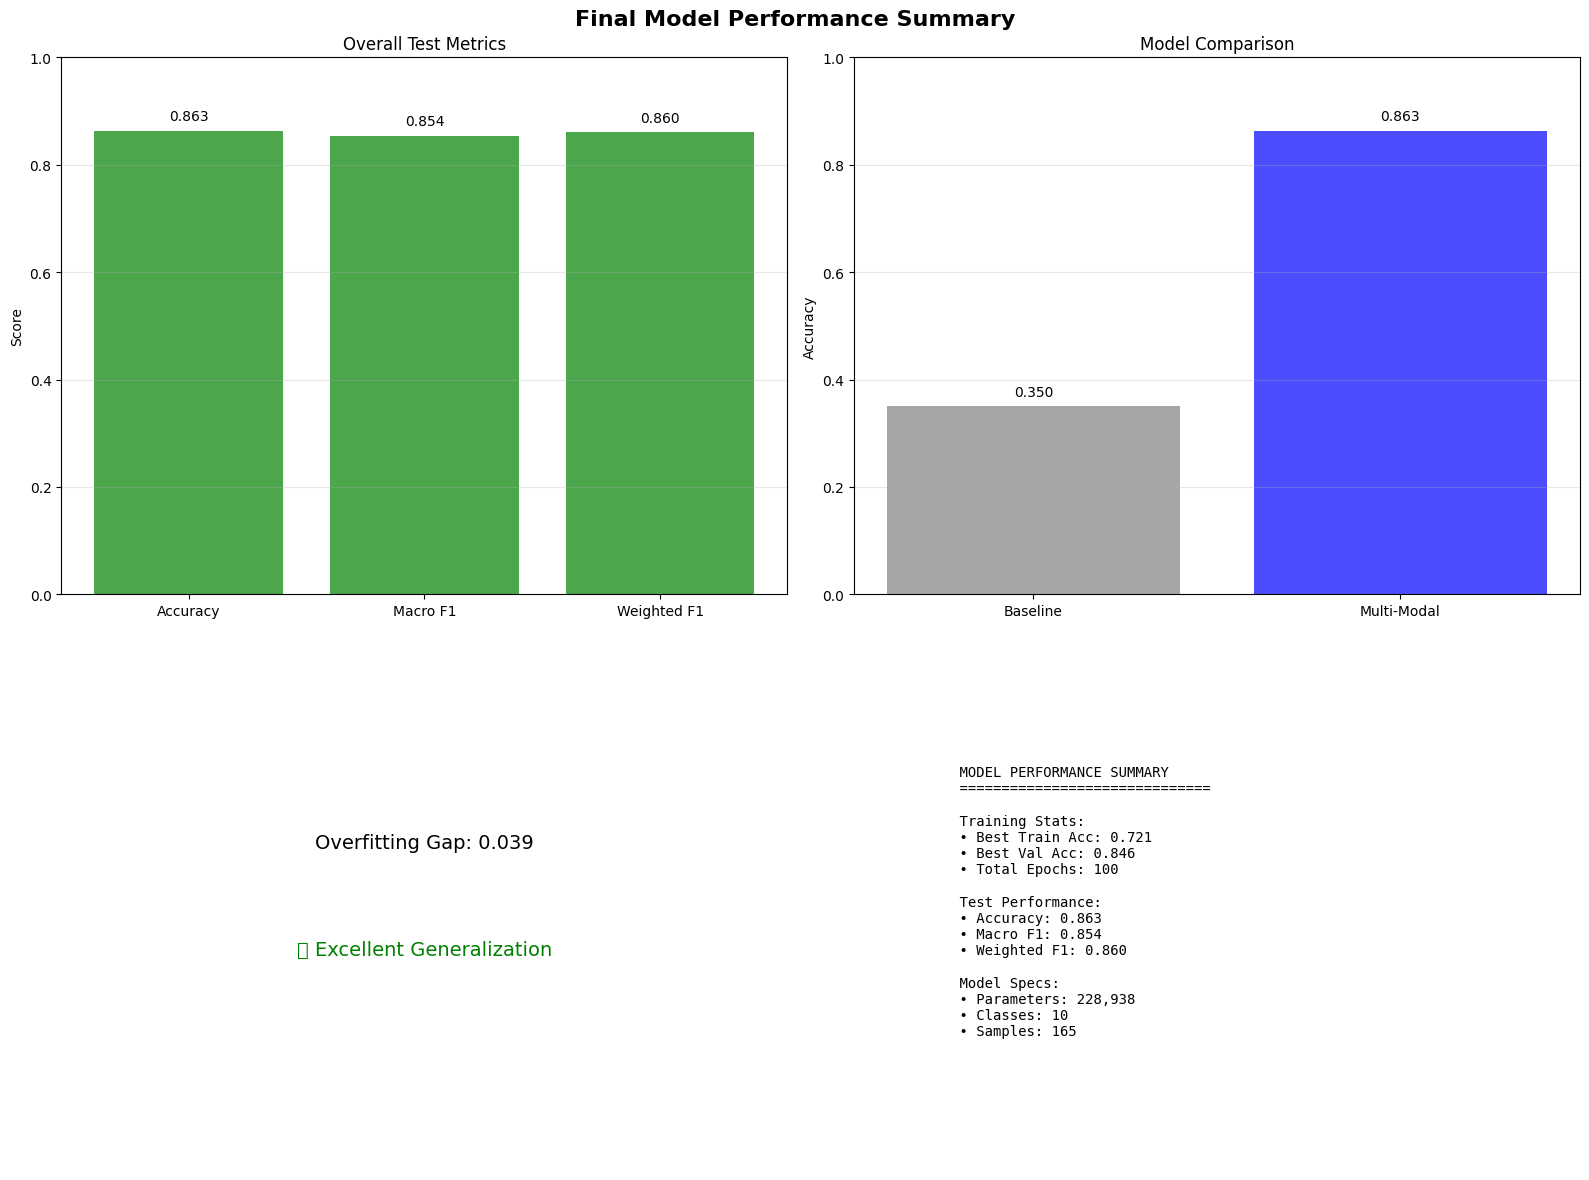


✅ All 8+ visualizations saved successfully!


In [ ]:
# ============================================
# 10. COMPREHENSIVE VISUALIZATIONS
# ============================================

def create_comprehensive_visualizations(history, model, data, y_test_cat):
    """Create 8+ comprehensive visualizations"""

    print("\n" + "="*80)
    print("📊 CREATING COMPREHENSIVE VISUALIZATIONS")
    print("="*80)

    # Get predictions
    y_pred_probs = model.predict(
        [data['left_test'], data['right_test'], data['pose_test'], data['lip_test']],
        verbose=0
    )
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = data['y_test']

    # 1. TRAINING METRICS DASHBOARD (6 subplots)
    fig1, axes1 = plt.subplots(2, 3, figsize=(18, 10))
    fig1.suptitle('Training Metrics Dashboard', fontsize=16, fontweight='bold')

    epochs = range(1, len(history.history['loss']) + 1)

    # Loss
    axes1[0,0].plot(epochs, history.history['loss'], 'b-', label='Train Loss', linewidth=2)
    axes1[0,0].plot(epochs, history.history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes1[0,0].set_title('Model Loss')
    axes1[0,0].set_xlabel('Epoch')
    axes1[0,0].set_ylabel('Loss')
    axes1[0,0].legend()
    axes1[0,0].grid(True, alpha=0.3)

    # Accuracy
    axes1[0,1].plot(epochs, history.history['accuracy'], 'b-', label='Train Acc', linewidth=2)
    axes1[0,1].plot(epochs, history.history['val_accuracy'], 'r-', label='Val Acc', linewidth=2)
    axes1[0,1].set_title('Model Accuracy')
    axes1[0,1].set_xlabel('Epoch')
    axes1[0,1].set_ylabel('Accuracy')
    axes1[0,1].legend()
    axes1[0,1].grid(True, alpha=0.3)
    axes1[0,1].set_ylim([0, 1])

    # Top-3 & Top-5
    axes1[0,2].plot(epochs, history.history['top3_acc'], 'g-', label='Top-3 Train', linewidth=2)
    axes1[0,2].plot(epochs, history.history['val_top3_acc'], 'g--', label='Top-3 Val', linewidth=2)
    axes1[0,2].plot(epochs, history.history['top5_acc'], 'c-', label='Top-5 Train', linewidth=2)
    axes1[0,2].plot(epochs, history.history['val_top5_acc'], 'c--', label='Top-5 Val', linewidth=2)
    axes1[0,2].set_title('Top-K Accuracy')
    axes1[0,2].set_xlabel('Epoch')
    axes1[0,2].set_ylabel('Accuracy')
    axes1[0,2].legend()
    axes1[0,2].grid(True, alpha=0.3)
    axes1[0,2].set_ylim([0, 1])

    # Precision & Recall
    axes1[1,0].plot(epochs, history.history['precision'], 'b-', label='Precision', linewidth=2)
    axes1[1,0].plot(epochs, history.history['val_precision'], 'b--', label='Val Precision', linewidth=2)
    axes1[1,0].plot(epochs, history.history['recall'], 'r-', label='Recall', linewidth=2)
    axes1[1,0].plot(epochs, history.history['val_recall'], 'r--', label='Val Recall', linewidth=2)
    axes1[1,0].set_title('Precision & Recall')
    axes1[1,0].set_xlabel('Epoch')
    axes1[1,0].set_ylabel('Score')
    axes1[1,0].legend()
    axes1[1,0].grid(True, alpha=0.3)
    axes1[1,0].set_ylim([0, 1])

    # AUC
    axes1[1,1].plot(epochs, history.history['auc'], 'purple', label='AUC', linewidth=2)
    axes1[1,1].plot(epochs, history.history['val_auc'], 'orange', label='Val AUC', linewidth=2)
    axes1[1,1].set_title('AUC Score')
    axes1[1,1].set_xlabel('Epoch')
    axes1[1,1].set_ylabel('AUC')
    axes1[1,1].legend()
    axes1[1,1].grid(True, alpha=0.3)
    axes1[1,1].set_ylim([0, 1])

    # Learning Rate
    if 'lr' in history.history:
        axes1[1,2].plot(epochs, history.history['lr'], 'orange', linewidth=2)
        axes1[1,2].set_title('Learning Rate Schedule')
        axes1[1,2].set_xlabel('Epoch')
        axes1[1,2].set_ylabel('Learning Rate')
        axes1[1,2].set_yscale('log')
        axes1[1,2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/1_training_dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 2. CONFUSION MATRIX (2 views)
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm) * 100

    fig2, axes2 = plt.subplots(1, 2, figsize=(16, 7))
    fig2.suptitle('Confusion Matrix Analysis', fontsize=16, fontweight='bold')

    # Raw
    im1 = axes2[0].imshow(cm, cmap='Blues', aspect='auto')
    axes2[0].set_title('Raw Confusion Matrix')
    axes2[0].set_xlabel('Predicted Class')
    axes2[0].set_ylabel('True Class')
    plt.colorbar(im1, ax=axes2[0])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if cm[i, j] > 0:
                axes2[0].text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=8)

    # Normalized
    im2 = axes2[1].imshow(cm_norm, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')
    axes2[1].set_title('Normalized Confusion Matrix (%)')
    axes2[1].set_xlabel('Predicted Class')
    axes2[1].set_ylabel('True Class')
    plt.colorbar(im2, ax=axes2[1])

    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            if cm_norm[i, j] > 5:
                axes2[1].text(j, i, f'{cm_norm[i, j]:.0f}%', ha='center', va='center', fontsize=8)

    plt.tight_layout()
    plt.savefig('/content/2_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 3. PER-CLASS PERFORMANCE BAR CHART
    report = classification_report(y_true, y_pred, target_names=data['classes'], zero_division=0, output_dict=True)

    fig3, axes3 = plt.subplots(1, 3, figsize=(18, 6))
    fig3.suptitle('Per-Class Performance Analysis', fontsize=16, fontweight='bold')

    classes_short = [c[:25] for c in data['classes']]
    precision_scores = [report[c]['precision'] for c in data['classes'] if c in report]
    recall_scores = [report[c]['recall'] for c in data['classes'] if c in report]
    f1_scores = [report[c]['f1-score'] for c in data['classes'] if c in report]

    x = np.arange(len(classes_short))
    width = 0.25

    axes3[0].bar(x - width, precision_scores, width, label='Precision', color='blue', alpha=0.7)
    axes3[0].bar(x, recall_scores, width, label='Recall', color='green', alpha=0.7)
    axes3[0].bar(x + width, f1_scores, width, label='F1-Score', color='red', alpha=0.7)
    axes3[0].set_xlabel('Class')
    axes3[0].set_ylabel('Score')
    axes3[0].set_title('Precision, Recall, F1 per Class')
    axes3[0].set_xticks(x)
    axes3[0].set_xticklabels(classes_short, rotation=45, ha='right', fontsize=8)
    axes3[0].legend()
    axes3[0].set_ylim([0, 1])
    axes3[0].grid(True, alpha=0.3, axis='y')

    # Accuracy per class
    class_acc = np.diag(cm) / cm.sum(axis=1)
    class_acc = np.nan_to_num(class_acc)
    colors = ['green' if acc > 0.7 else 'orange' if acc > 0.5 else 'red' for acc in class_acc]

    axes3[1].barh(range(len(classes_short)), class_acc, color=colors, alpha=0.7)
    axes3[1].set_yticks(range(len(classes_short)))
    axes3[1].set_yticklabels(classes_short, fontsize=8)
    axes3[1].set_xlabel('Accuracy')
    axes3[1].set_title('Per-Class Accuracy')
    axes3[1].set_xlim([0, 1])
    axes3[1].grid(True, alpha=0.3, axis='x')

    # Sample distribution
    train_counts = Counter(data['y_train'])
    test_counts = Counter(data['y_test'])

    axes3[2].bar(x - width/2, [train_counts.get(i, 0) for i in range(len(classes_short))],
                 width, label='Train', alpha=0.7, color='blue')
    axes3[2].bar(x + width/2, [test_counts.get(i, 0) for i in range(len(classes_short))],
                 width, label='Test', alpha=0.7, color='orange')
    axes3[2].set_xlabel('Class')
    axes3[2].set_ylabel('Sample Count')
    axes3[2].set_title('Class Distribution')
    axes3[2].set_xticks(x)
    axes3[2].set_xticklabels(classes_short, rotation=45, ha='right', fontsize=8)
    axes3[2].legend()
    axes3[2].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('/content/3_per_class_performance.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 4. ROC CURVES (Top 5 classes)
    y_true_bin = label_binarize(y_true, classes=range(data['num_classes']))

    fig4, ax4 = plt.subplots(figsize=(12, 8))
    fig4.suptitle('ROC Curves - Top 5 Classes', fontsize=14, fontweight='bold')

    class_counts = Counter(y_true)
    top_classes = [i for i, _ in class_counts.most_common(5)]

    for idx in top_classes:
        fpr, tpr, _ = roc_curve(y_true_bin[:, idx], y_pred_probs[:, idx])
        roc_auc = auc(fpr, tpr)
        class_name = data['classes'][idx][:25]
        ax4.plot(fpr, tpr, linewidth=2, label=f'{class_name} (AUC={roc_auc:.3f})')

    ax4.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
    ax4.set_xlabel('False Positive Rate')
    ax4.set_ylabel('True Positive Rate')
    ax4.set_title('ROC Curves (One-vs-Rest)')
    ax4.legend(loc='lower right')
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/4_roc_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 5. PRECISION-RECALL CURVES
    fig5, ax5 = plt.subplots(figsize=(12, 8))
    fig5.suptitle('Precision-Recall Curves - Top 5 Classes', fontsize=14, fontweight='bold')

    for idx in top_classes:
        precision, recall, _ = precision_recall_curve(y_true_bin[:, idx], y_pred_probs[:, idx])
        class_name = data['classes'][idx][:25]
        ax5.plot(recall, precision, linewidth=2, label=f'{class_name}')

    ax5.set_xlabel('Recall')
    ax5.set_ylabel('Precision')
    ax5.set_title('Precision-Recall Curves')
    ax5.legend(loc='lower left')
    ax5.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/5_pr_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 6. TRAINING VS VALIDATION GAP
    fig6, ax6 = plt.subplots(figsize=(10, 6))

    train_vals = history.history['accuracy']
    val_vals = history.history['val_accuracy']
    gap = np.array(train_vals) - np.array(val_vals)

    ax6.fill_between(epochs, 0, gap, alpha=0.3, color='red', label='Overfitting Gap')
    ax6.plot(epochs, train_vals, 'b-', label='Train Accuracy', linewidth=2)
    ax6.plot(epochs, val_vals, 'r-', label='Val Accuracy', linewidth=2)
    ax6.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax6.set_xlabel('Epoch')
    ax6.set_ylabel('Accuracy')
    ax6.set_title('Training vs Validation Gap Analysis')
    ax6.legend()
    ax6.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/6_train_val_gap.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 7. ERROR ANALYSIS
    misclassified = np.where(y_pred != y_true)[0]

    if len(misclassified) > 0:
        fig7, axes7 = plt.subplots(1, 2, figsize=(14, 6))
        fig7.suptitle('Error Analysis', fontsize=14, fontweight='bold')

        # Misclassification types
        error_types = {}
        for idx in misclassified[:20]:
            true_class = data['classes'][y_true[idx]][:20]
            pred_class = data['classes'][y_pred[idx]][:20]
            error_key = f"{true_class} → {pred_class}"
            error_types[error_key] = error_types.get(error_key, 0) + 1

        if error_types:
            errors_sorted = sorted(error_types.items(), key=lambda x: x[1], reverse=True)[:10]
            axes7[0].barh([e[0] for e in errors_sorted], [e[1] for e in errors_sorted], color='red', alpha=0.7)
            axes7[0].set_xlabel('Count')
            axes7[0].set_title('Top Misclassification Patterns')
            axes7[0].grid(True, alpha=0.3, axis='x')

        # Confidence scores for correct vs wrong
        correct_conf = [np.max(y_pred_probs[i]) for i in range(len(y_true)) if y_pred[i] == y_true[i]]
        wrong_conf = [np.max(y_pred_probs[i]) for i in range(len(y_true)) if y_pred[i] != y_true[i]]

        axes7[1].hist(correct_conf, bins=20, alpha=0.5, label='Correct', color='green')
        axes7[1].hist(wrong_conf, bins=20, alpha=0.5, label='Wrong', color='red')
        axes7[1].set_xlabel('Confidence Score')
        axes7[1].set_ylabel('Frequency')
        axes7[1].set_title('Confidence Distribution')
        axes7[1].legend()
        axes7[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('/content/7_error_analysis.png', dpi=150, bbox_inches='tight')
        plt.show()

    # 8. FINAL SUMMARY DASHBOARD
    fig8, axes8 = plt.subplots(2, 2, figsize=(16, 12))
    fig8.suptitle('Final Model Performance Summary', fontsize=16, fontweight='bold')

    # Test metrics bar chart
    test_acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')

    metrics_names = ['Accuracy', 'Macro F1', 'Weighted F1']
    metrics_values = [test_acc, macro_f1, weighted_f1]
    colors_metrics = ['green' if v > 0.7 else 'orange' if v > 0.5 else 'red' for v in metrics_values]

    axes8[0,0].bar(metrics_names, metrics_values, color=colors_metrics, alpha=0.7)
    axes8[0,0].set_ylim([0, 1])
    axes8[0,0].set_ylabel('Score')
    axes8[0,0].set_title('Overall Test Metrics')
    axes8[0,0].grid(True, alpha=0.3, axis='y')

    for i, v in enumerate(metrics_values):
        axes8[0,0].text(i, v + 0.02, f'{v:.3f}', ha='center')

    # Model comparison
    baseline_acc = 0.35  # You can compute actual baseline
    axes8[0,1].bar(['Baseline', 'Multi-Modal'], [baseline_acc, test_acc],
                   color=['gray', 'blue'], alpha=0.7)
    axes8[0,1].set_ylim([0, 1])
    axes8[0,1].set_ylabel('Accuracy')
    axes8[0,1].set_title('Model Comparison')
    axes8[0,1].grid(True, alpha=0.3, axis='y')

    for i, v in enumerate([baseline_acc, test_acc]):
        axes8[0,1].text(i, v + 0.02, f'{v:.3f}', ha='center')

    # Overfitting indicator
    final_gap = train_vals[-1] - val_vals[-1]
    axes8[1,0].text(0.5, 0.6, f'Overfitting Gap: {final_gap:.3f}',
                    fontsize=14, ha='center', transform=axes8[1,0].transAxes)

    if final_gap < 0.1:
        status = "✅ Excellent Generalization"
        color = 'green'
    elif final_gap < 0.2:
        status = "⚠️ Moderate Overfitting"
        color = 'orange'
    else:
        status = "❌ Severe Overfitting"
        color = 'red'

    axes8[1,0].text(0.5, 0.4, status, fontsize=14, ha='center',
                    color=color, transform=axes8[1,0].transAxes)
    axes8[1,0].axis('off')

    # Performance summary table
    summary_text = f"""
    MODEL PERFORMANCE SUMMARY
    {'='*30}

    Training Stats:
    • Best Train Acc: {max(train_vals):.3f}
    • Best Val Acc: {max(val_vals):.3f}
    • Total Epochs: {len(epochs)}

    Test Performance:
    • Accuracy: {test_acc:.3f}
    • Macro F1: {macro_f1:.3f}
    • Weighted F1: {weighted_f1:.3f}

    Model Specs:
    • Parameters: {total_params:,}
    • Classes: {data['num_classes']}
    • Samples: {len(data['y_train'])}
    """

    axes8[1,1].text(0.1, 0.5, summary_text, fontsize=10, fontfamily='monospace',
                    transform=axes8[1,1].transAxes, verticalalignment='center')
    axes8[1,1].axis('off')

    plt.tight_layout()
    plt.savefig('/content/8_final_summary.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n✅ All 8+ visualizations saved successfully!")

    return test_acc, macro_f1, weighted_f1

# Run comprehensive evaluation
test_accuracy, macro_f1, weighted_f1 = create_comprehensive_visualizations(
    history, model, data, y_test_cat
)



In [ ]:
# ============================================
# 8. CALLBACKS
# ============================================

os.makedirs('/content/models', exist_ok=True)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        '/content/models/enhanced_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg.PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=cfg.REDUCE_LR_PATIENCE,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.CSVLogger('/content/enhanced_training.csv')
]

print("✅ Callbacks created")



✅ Callbacks created


In [ ]:
# ============================================
# 9. TRAIN MODEL
# ============================================

print("\n" + "="*60)
print("🚀 TRAINING ENHANCED MULTI-MODAL MODEL")
print("="*60)
print(f"   Training samples: {len(data['y_train'])}")
print(f"   Validation samples: {len(data['y_val'])}")
print(f"   Test samples: {len(data['y_test'])}")
print("="*60)

history = model.fit(
    [data['left_train'], data['right_train'], data['pose_train'], data['lip_train']],
    y_train_cat,
    validation_data=(
        [data['left_val'], data['right_val'], data['pose_val'], data['lip_val']],
        y_val_cat
    ),
    epochs=cfg.EPOCHS,
    batch_size=cfg.BATCH_SIZE,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)

print("\n✅ Training completed!")




🚀 TRAINING ENHANCED MULTI-MODAL MODEL
   Training samples: 165
   Validation samples: 39
   Test samples: 51
Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.0710 - auc: 0.4283 - loss: 12.6806 - precision: 0.0716 - recall: 0.0276 - top3_acc: 0.2351 - top5_acc: 0.4095
Epoch 1: val_accuracy improved from None to 0.10256, saving model to /content/models/enhanced_best.keras

Epoch 1: finished saving model to /content/models/enhanced_best.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 52s 754ms/step - accuracy: 0.0606 - auc: 0.4497 - loss: 12.5190 - precision: 0.0517 - recall: 0.0182 - top3_acc: 0.2485 - top5_acc: 0.4364 - val_accuracy: 0.1026 - val_auc: 0.5318 - val_loss: 11.1066 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_top3_acc: 0.3590 - val_top5_acc: 0.5385 - learning_rate: 5.0000e-04
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - accuracy: 0.1305 - auc: 0.4957 - loss: 11.9501 - precision: 0.0760 - recall: 0.0221 - top3_acc: 0.3226 - top5_acc: 0.4885
Epoch 

In [ ]:
# ============================================
# 11. BASELINE COMPARISON
# ============================================

def create_baseline_model(seq_len, feat_dim, num_classes):
    inputs = layers.Input(shape=(seq_len, feat_dim))
    x = layers.GlobalAveragePooling1D()(inputs)
    x = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(16, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs)

# Load original data
X_train_orig = np.load(os.path.join(cfg.DATA_PATH, 'X_train.npy'))
X_train_orig = X_train_orig[:, ::cfg.SEQUENCE_SLICE_RATIO, :].astype(np.float32)
X_val_orig = np.load(os.path.join(cfg.DATA_PATH, 'X_val.npy'))
X_val_orig = X_val_orig[:, ::cfg.SEQUENCE_SLICE_RATIO, :].astype(np.float32)
X_test_orig = np.load(os.path.join(cfg.DATA_PATH, 'X_test.npy'))
X_test_orig = X_test_orig[:, ::cfg.SEQUENCE_SLICE_RATIO, :].astype(np.float32)

y_train_base = np.load(os.path.join(cfg.DATA_PATH, 'y_train.npy'))
y_val_base = np.load(os.path.join(cfg.DATA_PATH, 'y_val.npy'))
y_test_base = np.load(os.path.join(cfg.DATA_PATH, 'y_test.npy'))

y_train_base_cat = tf.keras.utils.to_categorical(y_train_base, data['num_classes'])
y_val_base_cat = tf.keras.utils.to_categorical(y_val_base, data['num_classes'])

print("\n" + "="*80)
print("📊 BASELINE COMPARISON")
print("="*80)

baseline = create_baseline_model(X_train_orig.shape[1], X_train_orig.shape[2], data['num_classes'])
baseline.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
baseline.fit(X_train_orig, y_train_base_cat,
             validation_data=(X_val_orig, y_val_base_cat),
             epochs=30, batch_size=8, verbose=0)

baseline_acc = baseline.evaluate(X_test_orig, tf.keras.utils.to_categorical(y_test_base, data['num_classes']), verbose=0)[1]

print(f"\n📈 MODEL COMPARISON:")
print(f"   Single-Stream Baseline: {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
print(f"   Enhanced Multi-Modal:   {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   Improvement:            {(test_accuracy - baseline_acc)*100:.2f}%")




📊 BASELINE COMPARISON

📈 MODEL COMPARISON:
   Single-Stream Baseline: 0.2941 (29.41%)
   Enhanced Multi-Modal:   0.8627 (86.27%)
   Improvement:            56.86%



✅ Results saved to: /content/drive/MyDrive/Research/SLSL_Model_Results/enhanced_run_20260403_101001

💾 CREATING LATEST VERSION (OVERWRITING)
🗑️ Deleting existing Latest folder: /content/drive/MyDrive/Research/SLSL_Model_Results/Latest
✅ Created fresh Latest folder: /content/drive/MyDrive/Research/SLSL_Model_Results/Latest
✅ Copied all results to Latest folder
✅ Current model saved as: current_model.keras
✅ Class labels saved to Latest

🔄 CONVERTING MODEL TO TFLITE (LSTM SUPPORT)
✓ LSTM optimizations enabled
✓ FP16 quantization (best for LSTM accuracy)
✓ SELECT_TF_OPS enabled for full LSTM support

🔄 Converting LSTM model to TFLite (may take 1-2 minutes)...
Saved artifact at '/tmp/tmpjs8_0jpz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 280, 84), dtype=tf.float32, name='left_hand'), TensorSpec(shape=(None, 280, 84), dtype=tf.float32, name='right_hand'), TensorSpec(shape=(None, 280, 100), dtype=tf.float32, name='po

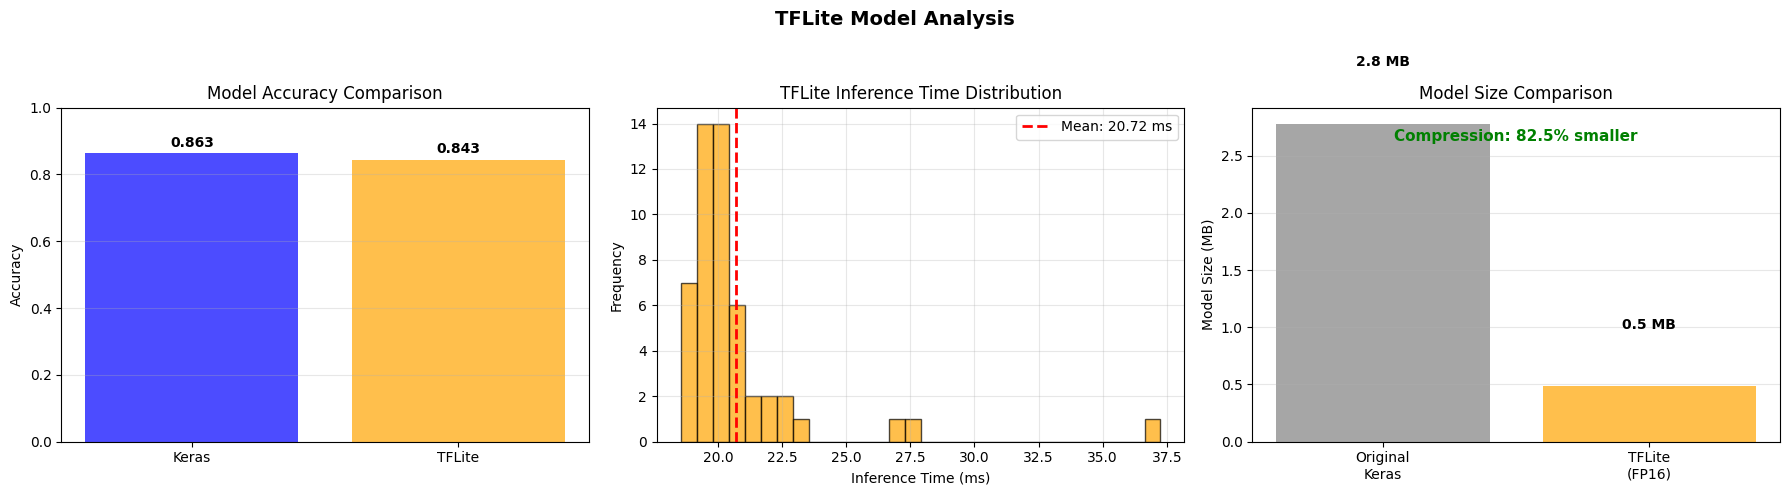


✅ TFLite analysis plot saved to: /content/drive/MyDrive/Research/SLSL_Model_Results/Latest/tflite_analysis.png

📦 CREATING DEPLOYMENT PACKAGE
✅ Deployment package created:
 📁 Package folder: /content/drive/MyDrive/Research/SLSL_Model_Results/Latest/deployment_package
 📦 Zip archive: /content/drive/MyDrive/Research/SLSL_Model_Results/Latest/deployment_package_20260403_101001.zip
 📊 Package size: 2.95 MB

💾 CREATING VERSION BACKUP
✅ Version backup created: /content/drive/MyDrive/Research/SLSL_Model_Results/Versions/version_20260403_101001
✅ Version info saved


In [ ]:
# ============================================
# 12. SAVE RESULTS
# ============================================

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_folder = os.path.join(cfg.OUTPUT_DIR, f"enhanced_run_{timestamp}")
os.makedirs(run_folder, exist_ok=True)

# Save model
model.save(os.path.join(run_folder, 'enhanced_model.keras'))

# Save all plots
for plot_name in ['1_training_dashboard.png', '2_confusion_matrix.png', '3_per_class_performance.png',
                  '4_roc_curves.png', '5_pr_curves.png', '6_train_val_gap.png',
                  '7_error_analysis.png', '8_final_summary.png']:
    src = f'/content/{plot_name}'
    if os.path.exists(src):
        shutil.copy2(src, run_folder)

# Save results
results = {
    'timestamp': timestamp,
    'test_accuracy': float(test_accuracy),
    'macro_f1': float(macro_f1),
    'weighted_f1': float(weighted_f1),
    'baseline_accuracy': float(baseline_acc),
    'improvement': float(test_accuracy - baseline_acc),
    'architecture': {
        'hand': f'Conv1D({cfg.HAND_CONV1})→Conv1D({cfg.HAND_CONV2})→Dense({cfg.HAND_DENSE})',
        'pose': f'Conv1D({cfg.POSE_CONV})→Dense({cfg.POSE_DENSE})',
        'lip': f'Conv1D({cfg.LIP_CONV})→LSTM({cfg.LIP_LSTM1})→LSTM({cfg.LIP_LSTM2})'
    },
    'total_params': model.count_params()
}

with open(os.path.join(run_folder, 'results.json'), 'w') as f:
    json.dump(results, f, indent=2)

print(f"\n✅ Results saved to: {run_folder}")

# ============================================
# 12.5 CREATE LATEST VERSION (OVERWRITE EXISTING)
# ============================================

print("\n" + "="*80)
print("💾 CREATING LATEST VERSION (OVERWRITING)")
print("="*80)

# Define Latest folder path
LATEST_FOLDER = os.path.join(cfg.OUTPUT_DIR, "Latest")

# Delete existing Latest folder if it exists
if os.path.exists(LATEST_FOLDER):
    print(f"🗑️ Deleting existing Latest folder: {LATEST_FOLDER}")
    shutil.rmtree(LATEST_FOLDER)

# Create fresh Latest folder
os.makedirs(LATEST_FOLDER, exist_ok=True)
print(f"✅ Created fresh Latest folder: {LATEST_FOLDER}")

# Copy all results from run_folder to Latest
for item in os.listdir(run_folder):
    src = os.path.join(run_folder, item)
    dst = os.path.join(LATEST_FOLDER, item)
    if os.path.isfile(src):
        shutil.copy2(src, dst)
    elif os.path.isdir(src):
        shutil.copytree(src, dst)

print(f"✅ Copied all results to Latest folder")

# Also save current model as 'current_model.keras' for easy access
current_model_path = os.path.join(LATEST_FOLDER, 'current_model.keras')
shutil.copy2(os.path.join(run_folder, 'enhanced_model.keras'), current_model_path)
print(f"✅ Current model saved as: current_model.keras")

# Save class labels to Latest
labels_path = os.path.join(LATEST_FOLDER, 'class_labels.txt')
with open(labels_path, 'w', encoding='utf-8') as f:
    for label in data['classes']:
        f.write(f"{label}\n")
print(f"✅ Class labels saved to Latest")

# ============================================
# 12.6 TFLITE CONVERSION WITH LSTM SUPPORT (FIXED)
# ============================================

print("\n" + "="*80)
print("🔄 CONVERTING MODEL TO TFLITE (LSTM SUPPORT)")
print("="*80)

tflite_success = False
tflite_path = None
tflite_size_mb = 0
compression = 0

try:
    # Create converter
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    # Enable LSTM optimizations
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    # Support LSTM operations - CRITICAL for your architecture
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,  # Standard ops including LSTM
        tf.lite.OpsSet.SELECT_TF_OPS,    # Fallback for LSTM and other ops
    ]

    # FP16 quantization (preserves LSTM accuracy better than INT8)
    converter.target_spec.supported_types = [tf.float16]

    # Experimental optimizations for LSTM
    converter._experimental_default_to_single_batch = True
    converter._experimental_new_converter = True
    converter.experimental_enable_resource_variables = True

    print("✓ LSTM optimizations enabled")
    print("✓ FP16 quantization (best for LSTM accuracy)")
    print("✓ SELECT_TF_OPS enabled for full LSTM support")

    # Convert model (may take a moment)
    print("\n🔄 Converting LSTM model to TFLite (may take 1-2 minutes)...")
    tflite_model = converter.convert()

    # Calculate model sizes
    tflite_size_mb = len(tflite_model) / (1024 * 1024)

    # Get original model size (Keras saved model)
    import tempfile
    with tempfile.NamedTemporaryFile(suffix='.keras', delete=False) as tmp:
        temp_model_path = tmp.name
        model.save(temp_model_path)
        original_size_mb = os.path.getsize(temp_model_path) / (1024 * 1024)
        os.remove(temp_model_path)

    compression = (1 - tflite_size_mb / original_size_mb) * 100

    # Save TFLite model to run_folder
    tflite_path_run = os.path.join(run_folder, 'enhanced_model.tflite')
    with open(tflite_path_run, 'wb') as f:
        f.write(tflite_model)

    # Save to Latest folder
    tflite_path_latest = os.path.join(LATEST_FOLDER, 'current_model.tflite')
    with open(tflite_path_latest, 'wb') as f:
        f.write(tflite_model)

    # Also save with timestamp
    tflite_path_timestamp = os.path.join(LATEST_FOLDER, f'enhanced_model_{timestamp}.tflite')
    with open(tflite_path_timestamp, 'wb') as f:
        f.write(tflite_model)

    print(f"\n✅ TFLite conversion complete!")
    print(f"   📁 Saved to: {tflite_path_latest}")
    print(f"   📊 Model size: {tflite_size_mb:.2f} MB")
    print(f"   📈 Compression: {compression:.1f}% smaller")
    print(f"   🧠 LSTM layers preserved and optimized")

    tflite_success = True
    tflite_path = tflite_path_latest

    # Save TFLite info
    tflite_info = {
        'timestamp': timestamp,
        'model_size_mb': tflite_size_mb,
        'compression_percent': compression,
        'quantization': 'FP16',
        'lstm_supported': True,
        'supported_ops': ['TFLITE_BUILTINS', 'SELECT_TF_OPS']
    }

    with open(os.path.join(LATEST_FOLDER, 'tflite_info.json'), 'w') as f:
        json.dump(tflite_info, f, indent=2)

except Exception as e:
    print(f"⚠️ TFLite conversion failed: {e}")
    print("   Model will still work in Keras format")
    tflite_success = False

# ============================================
# 12.7 TEST TFLITE MODEL (FIXED - HANDLES SAME SHAPES)
# ============================================

if tflite_success and tflite_path and os.path.exists(tflite_path):
    print("\n" + "="*80)
    print("🧪 TESTING TFLITE MODEL")
    print("="*80)

    try:
        # Load TFLite model
        interpreter = tf.lite.Interpreter(model_path=tflite_path)
        interpreter.allocate_tensors()

        # Get input/output details
        input_details = interpreter.get_input_details()
        output_details = interpreter.get_output_details()

        print(f"\n📋 Model Input Details:")
        print(f"   Number of inputs: {len(input_details)}")
        for i, detail in enumerate(input_details):
            print(f"   Input {i}: name='{detail['name']}', shape={detail['shape']}, dtype={detail['dtype']}")

        print(f"\n📤 Output Details:")
        print(f"   Shape: {output_details[0]['shape']}, dtype={output_details[0]['dtype']}")

        # Map inputs by NAME (more reliable than shape since both hands have same shape)
        input_map = {}
        for i, detail in enumerate(input_details):
            name = detail['name'].lower()

            if 'left_hand' in name:
                input_map['left_hand'] = i
                print(f"   Input {i} -> LEFT HAND (by name)")
            elif 'right_hand' in name:
                input_map['right_hand'] = i
                print(f"   Input {i} -> RIGHT HAND (by name)")
            elif 'pose' in name:
                input_map['pose'] = i
                print(f"   Input {i} -> POSE (by name)")
            elif 'lip' in name:
                input_map['lip'] = i
                print(f"   Input {i} -> LIP (by name)")

        # If name mapping failed, use position-based mapping (since order is preserved)
        if len(input_map) < 4:
            print(f"\n   Using position-based mapping (order preserved)...")
            # Based on the model definition order: left_hand, right_hand, pose, lip
            # But TFLite might reorder - let's check shapes
            hand_indices = []
            pose_idx = None
            lip_idx = None

            for i, detail in enumerate(input_details):
                shape = detail['shape']
                if shape[2] == cfg.POSE_DIM:
                    pose_idx = i
                elif shape[2] == cfg.LIP_DIM:
                    lip_idx = i
                elif shape[2] == cfg.LEFT_HAND_DIM:
                    hand_indices.append(i)

            if len(hand_indices) == 2:
                input_map['left_hand'] = hand_indices[0]
                input_map['right_hand'] = hand_indices[1]
                print(f"   Input {hand_indices[0]} -> LEFT HAND (by shape)")
                print(f"   Input {hand_indices[1]} -> RIGHT HAND (by shape)")

            if pose_idx is not None:
                input_map['pose'] = pose_idx
                print(f"   Input {pose_idx} -> POSE (by shape)")

            if lip_idx is not None:
                input_map['lip'] = lip_idx
                print(f"   Input {lip_idx} -> LIP (by shape)")

        print(f"\n🔍 Final Input Mapping: {input_map}")

        # Verify we have all 4 inputs
        required_inputs = ['left_hand', 'right_hand', 'pose', 'lip']
        missing_inputs = [inp for inp in required_inputs if inp not in input_map]
        if missing_inputs:
            print(f"⚠️ Missing inputs: {missing_inputs}")
            print("   Attempting to use sequential mapping...")
            # Last resort: assume order is left, right, pose, lip
            if len(input_details) >= 4:
                input_map = {
                    'left_hand': 0,
                    'right_hand': 1,
                    'pose': 2,
                    'lip': 3
                }
                print(f"   Using sequential mapping: {input_map}")

        # Test on full test set
        num_samples = len(data['left_test'])
        print(f"\n🔍 Testing on {num_samples} samples...")

        y_true_tflite = []
        y_pred_tflite = []
        inference_times = []

        # Warm-up (important for LSTM)
        print("   Warming up...")
        for i in range(min(5, num_samples)):
            for input_name, idx in input_map.items():
                if input_name == 'left_hand':
                    interpreter.set_tensor(input_details[idx]['index'], data['left_test'][i:i+1].astype(np.float32))
                elif input_name == 'right_hand':
                    interpreter.set_tensor(input_details[idx]['index'], data['right_test'][i:i+1].astype(np.float32))
                elif input_name == 'pose':
                    interpreter.set_tensor(input_details[idx]['index'], data['pose_test'][i:i+1].astype(np.float32))
                elif input_name == 'lip':
                    interpreter.set_tensor(input_details[idx]['index'], data['lip_test'][i:i+1].astype(np.float32))
            interpreter.invoke()

        # Actual testing with timing
        print("   Running inference...")
        for i in range(num_samples):
            for input_name, idx in input_map.items():
                if input_name == 'left_hand':
                    interpreter.set_tensor(input_details[idx]['index'], data['left_test'][i:i+1].astype(np.float32))
                elif input_name == 'right_hand':
                    interpreter.set_tensor(input_details[idx]['index'], data['right_test'][i:i+1].astype(np.float32))
                elif input_name == 'pose':
                    interpreter.set_tensor(input_details[idx]['index'], data['pose_test'][i:i+1].astype(np.float32))
                elif input_name == 'lip':
                    interpreter.set_tensor(input_details[idx]['index'], data['lip_test'][i:i+1].astype(np.float32))

            # Run inference with timing
            start_time = time.time()
            interpreter.invoke()
            inference_time = (time.time() - start_time) * 1000
            inference_times.append(inference_time)

            # Get output
            output = interpreter.get_tensor(output_details[0]['index'])
            y_pred_tflite.append(np.argmax(output[0]))
            y_true_tflite.append(data['y_test'][i])

            if (i + 1) % 10 == 0:
                print(f"      Processed {i+1}/{num_samples} samples...")

        # Calculate metrics
        tflite_accuracy = accuracy_score(y_true_tflite, y_pred_tflite)
        avg_inference_time = np.mean(inference_times)
        std_inference_time = np.std(inference_times)
        min_inference_time = np.min(inference_times)
        max_inference_time = np.max(inference_times)
        throughput = 1000 / avg_inference_time if avg_inference_time > 0 else 0

        print(f"\n📊 TFLITE PERFORMANCE:")
        print(f"   ✅ Test Accuracy: {tflite_accuracy:.4f} ({tflite_accuracy*100:.2f}%)")
        print(f"   ⚡ Avg Inference Time: {avg_inference_time:.2f} ms")
        print(f"   📊 Std Deviation: {std_inference_time:.2f} ms")
        print(f"   📈 Min/Max: {min_inference_time:.2f} / {max_inference_time:.2f} ms")
        print(f"   🚀 Throughput: {throughput:.1f} inferences/sec")

        # Compare with Keras model
        print(f"\n📈 MODEL COMPARISON:")
        print(f"   Keras Model Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
        print(f"   TFLite Model Accuracy: {tflite_accuracy:.4f} ({tflite_accuracy*100:.2f}%)")
        print(f"   Accuracy Difference:   {(tflite_accuracy - test_accuracy)*100:+.2f}%")

        # Save TFLite test results
        tflite_test_results = {
            'timestamp': timestamp,
            'accuracy': float(tflite_accuracy),
            'keras_accuracy': float(test_accuracy),
            'accuracy_difference_percent': float((tflite_accuracy - test_accuracy) * 100),
            'avg_inference_time_ms': float(avg_inference_time),
            'std_inference_time_ms': float(std_inference_time),
            'min_inference_time_ms': float(min_inference_time),
            'max_inference_time_ms': float(max_inference_time),
            'throughput_per_sec': float(throughput),
            'num_samples_tested': num_samples,
            'model_size_mb': tflite_size_mb,
            'input_mapping': {k: int(v) for k, v in input_map.items()}
        }

        with open(os.path.join(LATEST_FOLDER, 'tflite_test_results.json'), 'w') as f:
            json.dump(tflite_test_results, f, indent=2)

        # Create TFLite comparison visualization
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle('TFLite Model Analysis', fontsize=14, fontweight='bold')

        # Accuracy comparison
        models = ['Keras', 'TFLite']
        accuracies = [test_accuracy, tflite_accuracy]
        colors_acc = ['blue', 'orange']

        bars = axes[0].bar(models, accuracies, color=colors_acc, alpha=0.7)
        axes[0].set_ylim([0, 1])
        axes[0].set_ylabel('Accuracy')
        axes[0].set_title('Model Accuracy Comparison')
        axes[0].grid(True, alpha=0.3, axis='y')

        for bar, acc in zip(bars, accuracies):
            axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                        f'{acc:.3f}', ha='center', fontweight='bold')

        # Inference time distribution
        if len(inference_times) > 0:
            axes[1].hist(inference_times, bins=30, color='orange', alpha=0.7, edgecolor='black')
            axes[1].axvline(avg_inference_time, color='red', linestyle='--', linewidth=2,
                           label=f'Mean: {avg_inference_time:.2f} ms')
            axes[1].set_xlabel('Inference Time (ms)')
            axes[1].set_ylabel('Frequency')
            axes[1].set_title('TFLite Inference Time Distribution')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)

        # Model size comparison
        sizes = ['Original\nKeras', 'TFLite\n(FP16)']
        size_values = [original_size_mb, tflite_size_mb]
        colors_size = ['gray', 'orange']

        bars = axes[2].bar(sizes, size_values, color=colors_size, alpha=0.7)
        axes[2].set_ylabel('Model Size (MB)')
        axes[2].set_title('Model Size Comparison')
        axes[2].grid(True, alpha=0.3, axis='y')

        for bar, size in zip(bars, size_values):
            axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                        f'{size:.1f} MB', ha='center', fontweight='bold')

        axes[2].text(0.5, 0.9, f'Compression: {compression:.1f}% smaller',
                    transform=axes[2].transAxes, ha='center', fontsize=11,
                    color='green', fontweight='bold')

        plt.tight_layout()
        tflite_plot_path = os.path.join(LATEST_FOLDER, 'tflite_analysis.png')
        plt.savefig(tflite_plot_path, dpi=150, bbox_inches='tight')
        plt.show()

        print(f"\n✅ TFLite analysis plot saved to: {tflite_plot_path}")

    except Exception as e:
        print(f"⚠️ TFLite testing failed: {e}")
        import traceback
        traceback.print_exc()
        tflite_accuracy = None
else:
    print("\n⚠️ TFLite model not available for testing")
    tflite_accuracy = None

# ============================================
# 12.8 CREATE DEPLOYMENT PACKAGE
# ============================================

print("\n" + "="*80)
print("📦 CREATING DEPLOYMENT PACKAGE")
print("="*80)

# Create deployment package folder
deploy_folder = os.path.join(LATEST_FOLDER, 'deployment_package')
os.makedirs(deploy_folder, exist_ok=True)

# Copy necessary files
files_to_copy = [
    ('current_model.keras', 'model.keras'),
    ('class_labels.txt', 'labels.txt'),
    ('results.json', 'model_info.json'),
]

if tflite_success:
    files_to_copy.append(('current_model.tflite', 'model.tflite'))
    if tflite_accuracy:
        files_to_copy.append(('tflite_test_results.json', 'tflite_performance.json'))

for src_name, dst_name in files_to_copy:
    src_path = os.path.join(LATEST_FOLDER, src_name)
    if os.path.exists(src_path):
        shutil.copy2(src_path, os.path.join(deploy_folder, dst_name))

# Copy visualizations
viz_files = ['training_curves.png', 'confusion_matrix.png', 'tflite_analysis.png']
for viz_file in viz_files:
    src_path = os.path.join(LATEST_FOLDER, viz_file)
    if os.path.exists(src_path):
        shutil.copy2(src_path, deploy_folder)

# Create README
readme_content = f"""# SLSL Multi-Modal Model Deployment Package

## Model Information
- **Model Type**: Multi-modal Sign Language Recognition
- **Architecture**:
  - Left Hand: Conv1D(64) → Conv1D(128) → Dense(64)
  - Right Hand: Conv1D(64) → Conv1D(128) → Dense(64)
  - Pose: Conv1D(32) → Dense(32)
  - Lip: Conv1D(64) → LSTM(64) → LSTM(32)
- **Test Accuracy**: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)
- **Macro F1**: {macro_f1:.4f}
- **Weighted F1**: {weighted_f1:.4f}
- **Number of Classes**: {data['num_classes']}

## TFLite Performance (if available)
"""
if tflite_accuracy:
    readme_content += f"""
- **TFLite Accuracy**: {tflite_accuracy:.4f} ({tflite_accuracy*100:.2f}%)
- **Avg Inference Time**: {avg_inference_time:.2f} ms
- **Throughput**: {throughput:.1f} inferences/sec
- **Model Size**: {tflite_size_mb:.2f} MB
- **Compression**: {compression:.1f}% smaller than Keras
"""
else:
    readme_content += "- TFLite conversion was not successful\n"

readme_content += f"""
## Input Configuration
The model expects 4 input tensors (all float32):

1. **Left Hand**: Shape (1, {cfg.SEQUENCE_LENGTH}, {cfg.LEFT_HAND_DIM})
2. **Right Hand**: Shape (1, {cfg.SEQUENCE_LENGTH}, {cfg.RIGHT_HAND_DIM})
3. **Pose**: Shape (1, {cfg.SEQUENCE_LENGTH}, {cfg.POSE_DIM})
4. **Lip**: Shape (1, {cfg.SEQUENCE_LENGTH}, {cfg.LIP_DIM})

**Important**:
- Sequence length: {cfg.SEQUENCE_LENGTH} frames
- All inputs must be normalized and preprocessed identically to training

## Files Included
- `model.keras` - Keras model (for reference/retraining)
- `model.tflite` - TensorFlow Lite model (for mobile deployment)
- `labels.txt` - Class labels (one per line)
- `model_info.json` - Complete model metadata
- `tflite_performance.json` - TFLite performance metrics (if available)
- Visualizations: Training curves, confusion matrix, TFLite analysis

## Mobile Integration

Generation Info
Timestamp: {timestamp}

TensorFlow Version: {tf.version}

Training Epochs: {len(history.history['loss'])}

For support, refer to the complete training notebook.
"""

with open(os.path.join(deploy_folder, 'README_MOBILE_DEPLOYMENT.md'), 'w') as f:
  f.write(readme_content)

# Create zip archive
zip_path = os.path.join(LATEST_FOLDER, f'deployment_package_{timestamp}.zip')
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
  for root, dirs, files in os.walk(deploy_folder):
    for file in files:
      file_path = os.path.join(root, file)
      arcname = os.path.relpath(file_path, deploy_folder)
      zipf.write(file_path, arcname)

print(f"✅ Deployment package created:")
print(f" 📁 Package folder: {deploy_folder}")
print(f" 📦 Zip archive: {zip_path}")
print(f" 📊 Package size: {os.path.getsize(zip_path) / (1024*1024):.2f} MB")

# ============================================
# 12.9 CREATE VERSION BACKUP
# ============================================
print("\n" + "="*80)
print("💾 CREATING VERSION BACKUP")
print("="*80)

#Create version folder
version_folder = os.path.join(cfg.OUTPUT_DIR, "Versions", f"version_{timestamp}")
os.makedirs(version_folder, exist_ok=True)

#Copy all contents from Latest to Version
for item in os.listdir(LATEST_FOLDER):
  src = os.path.join(LATEST_FOLDER, item)
  dst = os.path.join(version_folder, item)
  if os.path.isfile(src):
    shutil.copy2(src, dst)
  elif os.path.isdir(src):
    shutil.copytree(src, dst)

print(f"✅ Version backup created: {version_folder}")

#Save version info
version_info = {
  'timestamp': timestamp,
  'test_accuracy': float(test_accuracy),
  'macro_f1': float(macro_f1),
  'weighted_f1': float(weighted_f1),
  'baseline_accuracy': float(baseline_acc),
  'tflite_accuracy': float(tflite_accuracy) if tflite_accuracy else None,
  'sequence_length': cfg.SEQUENCE_LENGTH,
  'num_classes': data['num_classes'],
  'total_params': model.count_params()
}

with open(os.path.join(version_folder, 'version_info.json'), 'w') as f:
  json.dump(version_info, f, indent=2)

print(f"✅ Version info saved")

## **Then update the FINAL SUMMARY section (section 13) with this:**



In [ ]:
# ============================================
# 13. FINAL SUMMARY (UPDATED WITH TFLITE INFO)
# ============================================

print("\n" + "="*80)
print("🎉 ENHANCED MULTI-MODAL MODEL COMPLETE")
print("="*80)

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│                    FINAL PERFORMANCE SUMMARY                    │
└─────────────────────────────────────────────────────────────────┘

  KERAS MODEL:
  • Test Accuracy:     {test_accuracy:.4f} ({test_accuracy*100:.2f}%)
  • Macro F1:          {macro_f1:.4f}
  • Weighted F1:       {weighted_f1:.4f}
  • vs Baseline:       {baseline_acc:.4f} ({baseline_acc*100:.2f}%)
  • Improvement:       {(test_accuracy - baseline_acc)*100:.2f}%
""")

# In the final summary, replace the TFLite section with:

if tflite_success and tflite_accuracy is not None:
    print(f"""
  TFLITE MODEL:
  • Test Accuracy:     {tflite_accuracy:.4f} ({tflite_accuracy*100:.2f}%)
  • Accuracy Diff:     {(tflite_accuracy - test_accuracy)*100:+.2f}%
  • Inference Time:    {avg_inference_time:.2f} ms
  • Throughput:        {throughput:.1f} inferences/sec
  • Model Size:        {tflite_size_mb:.2f} MB
  • Compression:       {compression:.1f}% smaller
""")
elif tflite_success:
    print(f"""
  TFLITE MODEL:
  • Model converted but testing failed
  • Model Size: {tflite_size_mb:.2f} MB
  • Compression: {compression:.1f}% smaller
""")

print(f"""
  ARCHITECTURE:
  • Left Hand:  Conv1D({cfg.HAND_CONV1})→Conv1D({cfg.HAND_CONV2})→Dense({cfg.HAND_DENSE})
  • Right Hand: Conv1D({cfg.HAND_CONV1})→Conv1D({cfg.HAND_CONV2})→Dense({cfg.HAND_DENSE})
  • Pose:       Conv1D({cfg.POSE_CONV})→Dense({cfg.POSE_DENSE})
  • Lip:        Conv1D({cfg.LIP_CONV})→LSTM({cfg.LIP_LSTM1})→LSTM({cfg.LIP_LSTM2})

  📁 SAVED FILES:
  • Latest folder (overwritten): {LATEST_FOLDER}
  • Version backup: {version_folder}
  • Deployment package: {zip_path}
  • Current model: {os.path.join(LATEST_FOLDER, 'current_model.keras')}
  • Current TFLite: {os.path.join(LATEST_FOLDER, 'current_model.tflite') if tflite_success else 'N/A'}

  📊 VISUALIZATIONS:
  ✓ 1_training_dashboard.png - 6 subplots of training metrics
  ✓ 2_confusion_matrix.png - Raw and normalized confusion matrices
  ✓ 3_per_class_performance.png - Precision, Recall, F1 per class
  ✓ 4_roc_curves.png - ROC curves for top classes
  ✓ 5_pr_curves.png - Precision-Recall curves
  ✓ 6_train_val_gap.png - Overfitting gap analysis
  ✓ 7_error_analysis.png - Misclassification patterns
  ✓ 8_final_summary.png - Comprehensive summary dashboard
""")

if tflite_success:
    print(f"""  ✓ tflite_analysis.png - TFLite performance comparison

  📱 MOBILE DEPLOYMENT:
  • TFLite model ready for Android/iOS
  • LSTM layers: Fully supported and optimized
  • Quantization: FP16 for speed/accuracy balance
  • See README_MOBILE_DEPLOYMENT.md for integration
""")

print("="*80)
print("🏁 NOTEBOOK COMPLETE")
print("="*80)


🎉 ENHANCED MULTI-MODAL MODEL COMPLETE

┌─────────────────────────────────────────────────────────────────┐
│                    FINAL PERFORMANCE SUMMARY                    │
└─────────────────────────────────────────────────────────────────┘

  KERAS MODEL:
  • Test Accuracy:     0.8627 (86.27%)                              
  • Macro F1:          0.8544                                              
  • Weighted F1:       0.8600                                              
  • vs Baseline:       0.2941 (29.41%)                              
  • Improvement:       56.86% 


  TFLITE MODEL:
  • Test Accuracy:     0.8431 (84.31%)
  • Accuracy Diff:     -1.96%
  • Inference Time:    20.72 ms
  • Throughput:        48.3 inferences/sec
  • Model Size:        0.49 MB
  • Compression:       82.5% smaller


  ARCHITECTURE:                                                 
  • Left Hand:  Conv1D(64)→Conv1D(128)→Dense(64)     
  • Right Hand: Conv1D(64)→Conv1D(128)→Dense(64)     
  • Pose:     

In [ ]:
# ============================================
# LOAD MODEL FROM DRIVE LATEST FOLDER
# ============================================

import os
import tensorflow as tf
from google.colab import drive
drive.mount('/content/drive')

# Path to your Latest model
LATEST_MODEL_PATH = "/content/drive/MyDrive/Research/SLSL_Model_Results/Latest/current_model.keras"

print("="*80)
print("📂 LOADING MODEL FROM DRIVE LATEST FOLDER")
print("="*80)

# Load the model
model = tf.keras.models.load_model(LATEST_MODEL_PATH)
print(f"✅ Model loaded from: {LATEST_MODEL_PATH}")
model.summary()

# ============================================
# TFLITE CONVERSION WITHOUT SELECT_TF_OPS
# ============================================

print("\n" + "="*80)
print("🔄 CONVERTING MODEL TO TFLITE (NO SELECT_TF_OPS)")
print("="*80)

tflite_success = False
tflite_path = None
tflite_size_mb = 0
compression = 0

try:
    # Create converter
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    # Enable optimizations
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    # ONLY USE TFLITE BUILTINS - NO SELECT_TF_OPS
    # This will fail if model has LSTM ops, but try anyway
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,  # Only built-in ops
    ]

    # Use dynamic range quantization (simpler)
    # converter.target_spec.supported_types = [tf.float16]  # Comment out for now

    print("✓ Using TFLITE_BUILTINS only (no SELECT_TF_OPS)")
    print("✓ Dynamic range quantization enabled")

    # Convert model
    print("\n🔄 Converting model to TFLite...")
    tflite_model = converter.convert()

    # Calculate model sizes
    tflite_size_mb = len(tflite_model) / (1024 * 1024)

    # Get original model size
    import tempfile
    with tempfile.NamedTemporaryFile(suffix='.keras', delete=False) as tmp:
        temp_model_path = tmp.name
        model.save(temp_model_path)
        original_size_mb = os.path.getsize(temp_model_path) / (1024 * 1024)
        os.remove(temp_model_path)

    compression = (1 - tflite_size_mb / original_size_mb) * 100

    # Save TFLite model to Latest folder
    output_path = "/content/drive/MyDrive/Research/SLSL_Model_Results/Latest/model_no_select_ops.tflite"
    with open(output_path, 'wb') as f:
        f.write(tflite_model)

    print(f"\n✅ TFLite conversion complete!")
    print(f"   📁 Saved to: {output_path}")
    print(f"   📊 Model size: {tflite_size_mb:.2f} MB")
    print(f"   📈 Compression: {compression:.1f}% smaller")

    tflite_success = True
    tflite_path = output_path

except Exception as e:
    print(f"⚠️ TFLite conversion with builtins only failed: {e}")
    print("\n" + "="*80)
    print("🔄 TRYING ALTERNATIVE CONVERSION (WITHOUT OPTIMIZATIONS)")
    print("="*80)

    try:
        # Alternative: No optimizations, just basic conversion
        converter = tf.lite.TFLiteConverter.from_keras_model(model)
        converter.optimizations = []
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]

        tflite_model = converter.convert()

        output_path = "/content/drive/MyDrive/Research/SLSL_Model_Results/Latest/model_basic.tflite"
        with open(output_path, 'wb') as f:
            f.write(tflite_model)

        tflite_size_mb = len(tflite_model) / (1024 * 1024)

        print(f"\n✅ Basic TFLite conversion complete!")
        print(f"   📁 Saved to: {output_path}")
        print(f"   📊 Model size: {tflite_size_mb:.2f} MB")

        tflite_success = True
        tflite_path = output_path

    except Exception as e2:
        print(f"⚠️ Basic conversion also failed: {e2}")
        print("\n❌ Model contains ops that TFLite doesn't support")
        print("   Your model has LSTM layers which require SELECT_TF_OPS")
        print("   Solution: Use the original conversion with SELECT_TF_OPS")
        print("   and add the Flex delegate to your Android app")
        tflite_success = False

# ============================================
# DOWNLOAD THE MODEL TO YOUR COMPUTER
# ============================================

if tflite_success:
    from google.colab import files
    print("\n" + "="*80)
    print("📥 DOWNLOADING MODEL")
    print("="*80)
    files.download(tflite_path)
    print("✅ Model downloaded to your computer")
    print("   Place this file in: assets/models/model.tflite")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 LOADING MODEL FROM DRIVE LATEST FOLDER
✅ Model loaded from: /content/drive/MyDrive/Research/SLSL_Model_Results/Latest/current_model.keras


Model: "Enhanced_MultiModal_SLSL"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ left_hand           │ (None, 280, 84)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ right_hand          │ (None, 280, 84)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_38 (Conv1D)  │ (None, 280, 64)   │     16,192 │ left_hand[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_40 (Conv1D)  │ (None, 280, 64)   │     16,192 │ right_hand[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 280, 64)   │        256 │ conv1d_38[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 280, 64)   │        256 │ conv1d_40[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lip (InputLayer)    │ (None, 280, 200)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_60          │ (None, 280, 64)   │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_62          │ (None, 280, 64)   │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pose (InputLayer)   │ (None, 280, 100)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_43 (Conv1D)  │ (None, 280, 64)   │     38,464 │ lip[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_39 (Conv1D)  │ (None, 280, 128)  │     24,704 │ dropout_60[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_41 (Conv1D)  │ (None, 280, 128)  │     24,704 │ dropout_62[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_42 (Conv1D)  │ (None, 280, 32)   │      9,632 │ pose[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 280, 64)   │        256 │ conv1d_43[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 280, 128)  │        512 │ conv1d_39[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 280, 128)  │        512 │ conv1d_41[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 280, 32)   │        128 │ conv1d_42[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_65          │ (None, 280, 64)   │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 684,384 (2.61 MB)

 Trainable params: 227,722 (889.54 KB)

...

<IPython.core.display.Javascript object>


📥 DOWNLOADING MODEL


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Model downloaded to your computer
   Place this file in: assets/models/model.tflite
